# Load Dataset

In [1]:
from pathlib import Path

import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

SEED = 42

PROJECT = Path("/content/drive/MyDrive/amex_project")
PROCESSED = PROJECT / "data" / "processed"
MODEL_DIR = PROJECT / "models"
REPORT_DIR = PROJECT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


In [2]:
sample = pd.read_parquet(
    PROCESSED / "customer_history_30k.parquet"
)

sample_labels = pd.read_parquet(
    PROCESSED / "customer_labels_30k.parquet"
)

# 이미 정해놓은 고객 분할도 그대로 불러오기
split_map = pd.read_parquet(
    PROCESSED / "customer_split_30k.parquet"
)

In [3]:
CAT_COLS = [
    "B_30", "B_38", "D_114", "D_116", "D_117",
    "D_120", "D_126", "D_63", "D_64", "D_66", "D_68",
]

NUM_COLS = [
    col for col in sample.columns
    if col not in ["customer_ID", "S_2"] + CAT_COLS
]

train_ids = split_map.loc[
    split_map["split"] == "train", "customer_ID"
].to_numpy()

valid_ids = split_map.loc[
    split_map["split"] == "valid", "customer_ID"
].to_numpy()

holdout_ids = split_map.loc[
    split_map["split"] == "holdout", "customer_ID"
].to_numpy()

In [4]:
assert sample_labels["customer_ID"].is_unique
assert split_map["customer_ID"].is_unique

assert (
    set(sample["customer_ID"])
    == set(sample_labels["customer_ID"])
    == set(split_map["customer_ID"])
)

assert not sample.duplicated(["customer_ID", "S_2"]).any()

print("고객 이력:", sample.shape)
print("고객 정답:", sample_labels.shape)
print(f"수치형 {len(NUM_COLS)}개 / 범주형 {len(CAT_COLS)}개")
print(
    f"학습 {len(train_ids):,}명 / "
    f"검증 {len(valid_ids):,}명 / "
    f"최종 평가 {len(holdout_ids):,}명"
)

고객 이력: (361527, 190)
고객 정답: (30000, 2)
수치형 177개 / 범주형 11개
학습 18,000명 / 검증 6,000명 / 최종 평가 6,000명


In [5]:
latest = (
    sample
    .sort_values(["customer_ID", "S_2"])
    .drop_duplicates("customer_ID", keep="last")
)

baseline = latest.merge(
    sample_labels,
    on="customer_ID",
    how="inner",
    validate="one_to_one",
).set_index("customer_ID").sort_index()

assert len(baseline) == 30_000
assert baseline["target"].notna().all()

print("기준 모델 데이터 크기:", baseline.shape)
display(baseline.head())

기준 모델 데이터 크기: (30000, 190)


,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,D_42,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
customer_ID,,,,,,,,,,,,,,,,,,,,,
00001b22f846c82c51f6e3958ccd81970162bae8b007e80662ef27519fcc18c1,2018-03-12,0.880875,0.009704,0.004284,0.812649,0.006450,NaN,0.003796,0.007196,NaN,...,NaN,NaN,0.007383,0.006623,0.000964,NaN,0.002202,0.000834,0.003444,0
0000d17a1447b25a01e42e1ac56b091bb7cbb06317be4cb59b50fec59e0b6381,2018-03-23,1.009762,0.006181,-0.000886,1.006692,0.006112,0.116401,0.000824,0.149496,NaN,...,NaN,NaN,0.002262,0.005217,0.002153,NaN,0.001170,0.003350,0.000675,0
000333075fb8ec6d504539852eeeb762643562e701ac79b2101ab0f9471eeb5a,2018-03-23,0.703360,0.007655,0.030412,1.002236,0.008567,0.056552,0.006064,0.004148,NaN,...,NaN,NaN,0.009926,0.006285,0.004757,NaN,0.007618,0.006742,0.007675,1
0005a6ae24fd274640a237ea56c43b1ef9e32077ad168a90d464dcf2bd5976fb,2018-03-16,0.988091,0.238952,0.056075,1.006357,0.007237,0.082842,0.000598,0.005760,NaN,...,NaN,NaN,0.003747,0.002857,0.008170,NaN,0.006951,0.000186,0.009110,0
0005e52a3fa31b7eed49ceb576f011433ee2578833cd3f9d51c9dd9448a198ff,2018-03-26,0.602346,0.007705,0.497001,0.041690,0.500306,1.266421,0.001693,0.205796,0.076465,...,NaN,NaN,0.008639,0.007512,0.002536,NaN,0.008481,0.000773,0.003672,1


In [6]:
from sklearn.model_selection import train_test_split

SEED = 42

train_ids, remaining_ids = train_test_split(
    baseline.index.to_numpy(),
    test_size=0.4,
    stratify=baseline["target"],
    random_state=SEED,
)

valid_ids, holdout_ids = train_test_split(
    remaining_ids,
    test_size=0.5,
    stratify=baseline.loc[remaining_ids, "target"],
    random_state=SEED,
)

split_map = pd.concat([
    pd.DataFrame({"customer_ID": train_ids, "split": "train"}),
    pd.DataFrame({"customer_ID": valid_ids, "split": "valid"}),
    pd.DataFrame({"customer_ID": holdout_ids, "split": "holdout"}),
], ignore_index=True)

assert split_map["customer_ID"].is_unique

# 앞서 Drive 저장 단계에서 만든 PROCESSED 경로 사용
split_map.to_parquet(PROCESSED / "customer_split_30k.parquet", index=False)

display(split_map["split"].value_counts())

,count
split,
train,18000
valid,6000
holdout,6000


In [7]:
FEATURES = [
    col for col in baseline.columns
    if col not in ["S_2", "target"]
]

X_train = baseline.loc[train_ids, FEATURES].copy()
X_valid = baseline.loc[valid_ids, FEATURES].copy()

y_train = baseline.loc[train_ids, "target"]
y_valid = baseline.loc[valid_ids, "target"]

category_levels = {}

for col in CAT_COLS:
    levels = X_train[col].dropna().unique().tolist()
    category_levels[col] = levels

    cat_dtype = pd.CategoricalDtype(categories=levels)

    X_train[col] = X_train[col].astype(cat_dtype)
    X_valid[col] = X_valid[col].astype(cat_dtype)

print("학습:", X_train.shape)
print("검증:", X_valid.shape)

학습: (18000, 188)
검증: (6000, 188)


In [8]:
%pip install -q lightgbm

In [9]:
import lightgbm as lgb
import time

model = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=100,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=SEED,
    n_jobs=2,
    verbosity=-1,
)

started = time.perf_counter()

model.fit(
    X_train,
    y_train,
    categorical_feature=CAT_COLS,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=100,
            first_metric_only=True,
        ),
        lgb.log_evaluation(period=100),
    ],
)

training_seconds = time.perf_counter() - started

print(f"학습 시간: {training_seconds:.1f}초")
print("선택된 반복 횟수:", model.best_iteration_)

Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.952982	valid_0's binary_logloss: 0.24773
[200]	valid_0's auc: 0.955112	valid_0's binary_logloss: 0.23524
[300]	valid_0's auc: 0.954921	valid_0's binary_logloss: 0.235751
Early stopping, best iteration is:
[208]	valid_0's auc: 0.955163	valid_0's binary_logloss: 0.235106
Evaluated only: auc
학습 시간: 35.6초
선택된 반복 횟수: 208


In [10]:
import numpy as np
from sklearn.metrics import roc_auc_score

valid_pred = model.predict_proba(X_valid)[:, 1]

valid_results = pd.DataFrame({
    "customer_ID": X_valid.index,
    "target": y_valid.to_numpy(),
    "risk_score": valid_pred,
})

ranked = valid_results.sort_values(
    ["risk_score", "customer_ID"],
    ascending=[False, True],
)

top_n = int(np.ceil(len(ranked) * 0.10))
top_group = ranked.head(top_n)

auc = roc_auc_score(y_valid, valid_pred)
capture = top_group["target"].sum() / ranked["target"].sum()
precision = top_group["target"].mean()

metrics = pd.DataFrame([{
    "model": "latest_only_lightgbm",
    "valid_auc": auc,
    "top10_capture": capture,
    "top10_default_rate": precision,
    "best_iteration": model.best_iteration_,
    "training_seconds": training_seconds,
}])

print(f"검증 ROC-AUC: {auc:.4f}")
print(f"상위 10%의 부도 고객 포착률: {capture:.2%}")
print(f"상위 10% 그룹 내 부도율: {precision:.2%}")

검증 ROC-AUC: 0.9552
상위 10%의 부도 고객 포착률: 36.81%
상위 10% 그룹 내 부도율: 95.33%


In [11]:
import joblib

MODEL_DIR = PROJECT / "models"
REPORT_DIR = PROJECT / "reports"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(
    {
        "model": model,
        "features": FEATURES,
        "category_levels": category_levels,
        "seed": SEED,
    },
    MODEL_DIR / "latest_only_lightgbm.joblib",
)

metrics.to_csv(
    REPORT_DIR / "latest_only_metrics.csv",
    index=False,
)

valid_results.to_parquet(
    REPORT_DIR / "latest_only_valid_predictions.parquet",
    index=False,
)

print("모델과 검증 결과 저장 완료")

모델과 검증 결과 저장 완료


# 시각화

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import roc_curve, roc_auc_score
from matplotlib.ticker import PercentFormatter

# 기준 모델의 검증 예측 결과
plot_data = pd.read_parquet(
    REPORT_DIR / "latest_only_valid_predictions.parquet"
)

# 기준 모델
saved = joblib.load(
    MODEL_DIR / "latest_only_lightgbm.joblib"
)
baseline_model = saved["model"]

y_true = plot_data["target"].to_numpy()
y_score = plot_data["risk_score"].to_numpy()

print(f"시각화 대상: 검증 고객 {len(plot_data):,}명")

시각화 대상: 검증 고객 6,000명


In [13]:
# ① ROC
fpr, tpr, _ = roc_curve(y_true, y_score)
auc = roc_auc_score(y_true, y_score)

# ② 위험점수 높은 순서로 정렬한 누적 포착률
ranked = plot_data.sort_values(
    ["risk_score", "customer_ID"],
    ascending=[False, True],
).reset_index(drop=True)

customer_share = np.arange(1, len(ranked) + 1) / len(ranked)
default_capture = (
    ranked["target"].cumsum().to_numpy()
    / ranked["target"].sum()
)

top_n = int(np.ceil(len(ranked) * 0.10))
top10_capture = default_capture[top_n - 1]

# ③ 위험등급별 부도율
# 동점은 고객 ID 순서로 나누어 각 그룹의 크기를 맞춤
graded = plot_data.sort_values(
    ["risk_score", "customer_ID"],
    ascending=[True, True],
).reset_index(drop=True)

graded["risk_grade"] = pd.qcut(
    np.arange(len(graded)),
    q=10,
    labels=range(1, 11),
)

grade_summary = (
    graded.groupby("risk_grade", observed=True)
    .agg(
        customers=("target", "size"),
        defaults=("target", "sum"),
        default_rate=("target", "mean"),
    )
)

# ④ 변수 중요도: 분할로 얻은 학습 손실 감소량(gain)
importance = pd.Series(
    baseline_model.booster_.feature_importance(
        importance_type="gain"
    ),
    index=baseline_model.booster_.feature_name(),
)

# 전체 변수 중요도 합을 100%로 정규화
importance_pct = 100 * importance / importance.sum()
top_importance = importance_pct.nlargest(15).sort_values()

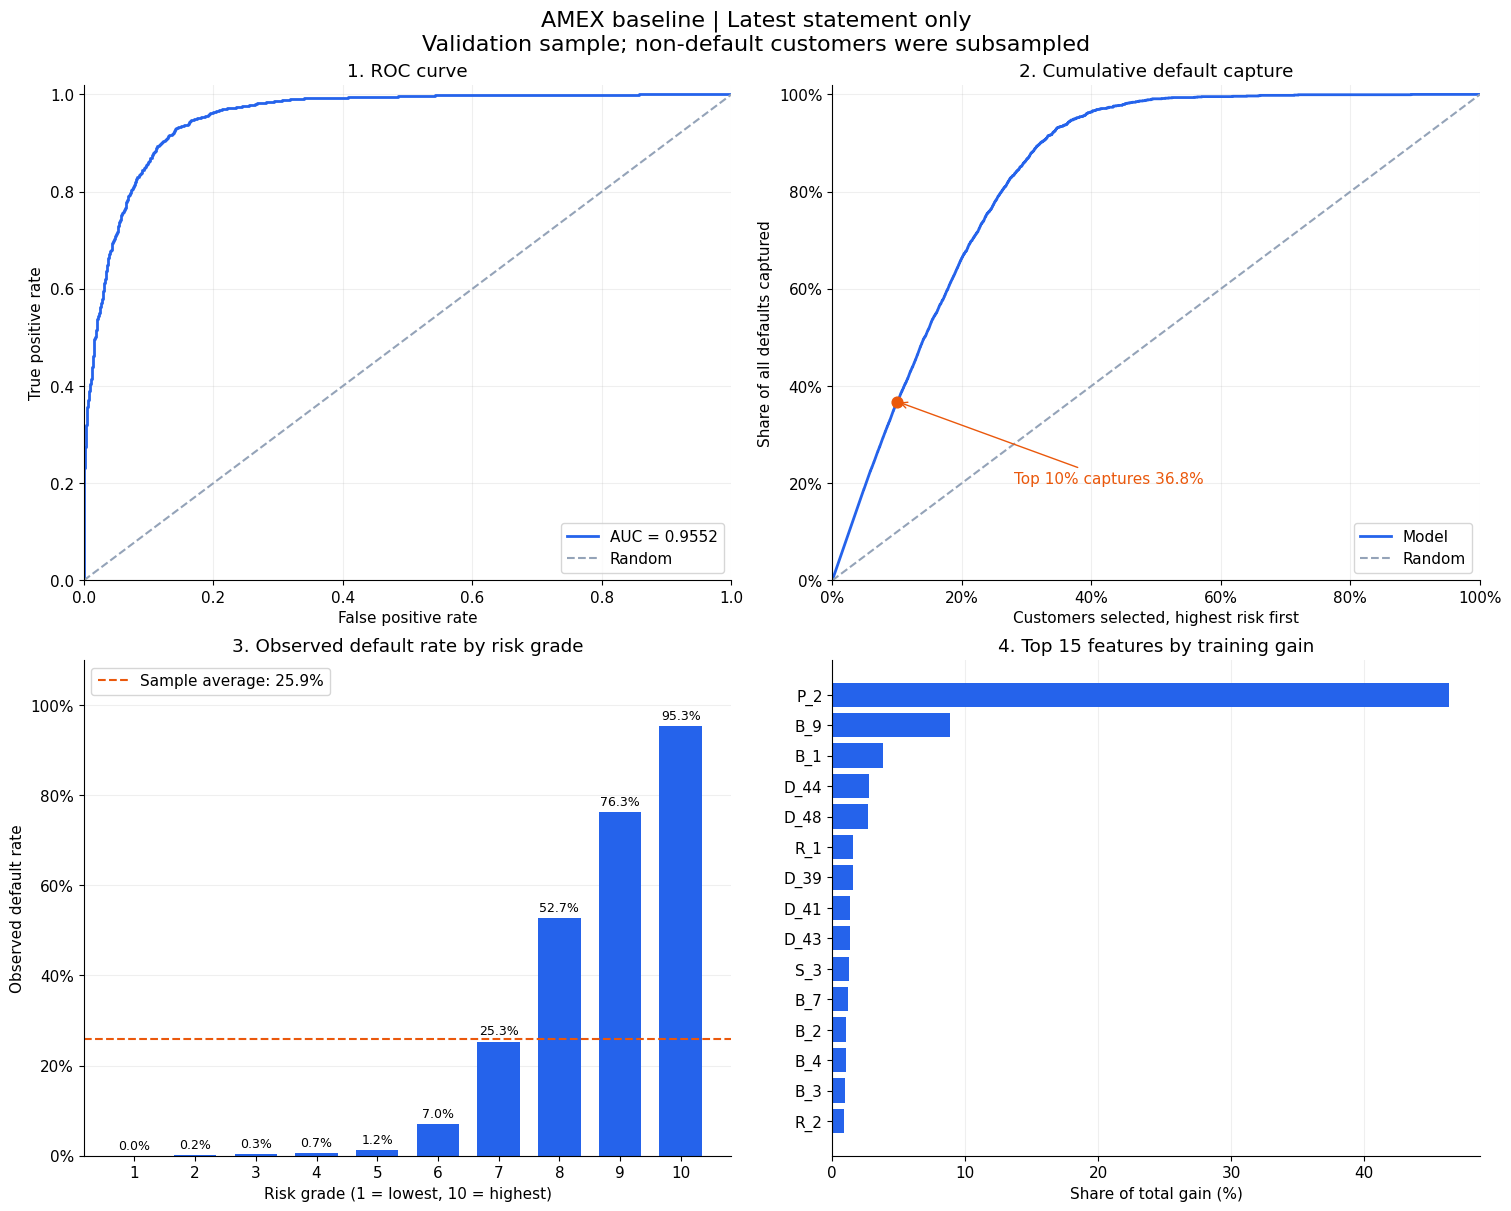

In [14]:
plt.rcParams.update({
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 12),
    constrained_layout=True,
)

blue = "#2563EB"
orange = "#EA580C"
gray = "#94A3B8"

# ① ROC 곡선
ax = axes[0, 0]

ax.plot(fpr, tpr, color=blue, lw=2, label=f"AUC = {auc:.4f}")
ax.plot([0, 1], [0, 1], "--", color=gray, label="Random")

ax.set(
    title="1. ROC curve",
    xlabel="False positive rate",
    ylabel="True positive rate",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend(loc="lower right")
ax.grid(alpha=0.2)

# ② 누적 포착률
ax = axes[0, 1]

ax.plot(
    np.r_[0, customer_share],
    np.r_[0, default_capture],
    color=blue,
    lw=2,
    label="Model",
)
ax.plot([0, 1], [0, 1], "--", color=gray, label="Random")

ax.scatter(
    customer_share[top_n - 1],
    top10_capture,
    color=orange,
    s=60,
    zorder=3,
)
ax.annotate(
    f"Top 10% captures {top10_capture:.1%}",
    xy=(customer_share[top_n - 1], top10_capture),
    xytext=(0.28, 0.20),
    arrowprops={"arrowstyle": "->", "color": orange},
    color=orange,
)

ax.set(
    title="2. Cumulative default capture",
    xlabel="Customers selected, highest risk first",
    ylabel="Share of all defaults captured",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc="lower right")
ax.grid(alpha=0.2)

# ③ 위험등급별 부도율
ax = axes[1, 0]

grades = grade_summary.index.astype(int)
rates = grade_summary["default_rate"]

ax.bar(grades, rates, color=blue, width=0.7)

ax.axhline(
    y_true.mean(),
    color=orange,
    linestyle="--",
    label=f"Sample average: {y_true.mean():.1%}",
)

for grade, rate in zip(grades, rates):
    ax.text(
        grade, rate + 0.015,
        f"{rate:.1%}",
        ha="center",
        fontsize=9,
    )

ax.set(
    title="3. Observed default rate by risk grade",
    xlabel="Risk grade (1 = lowest, 10 = highest)",
    ylabel="Observed default rate",
    ylim=(0, 1.10),
    xticks=range(1, 11),
)
ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(loc="upper left")
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)

# ④ 변수 중요도
ax = axes[1, 1]

ax.barh(
    top_importance.index,
    top_importance.values,
    color=blue,
)
ax.set(
    title="4. Top 15 features by training gain",
    xlabel="Share of total gain (%)",
)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

fig.suptitle(
    "AMEX baseline | Latest statement only\n"
    "Validation sample; non-default customers were subsampled",
    fontsize=16,
)

FIGURE_DIR = REPORT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig.savefig(
    FIGURE_DIR / "baseline_validation_dashboard.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()